# Detection + ReID Tracking Pipeline (MOT16)

End-to-end tracking: Mask R-CNN + ReID on MOT16.

**Pipeline:** Frame → Detect → Crop → ReID Embed → Hungarian Match → Track → Video

In [ ]:
import os
import random
import numpy as np
from pathlib import Path
from PIL import Image
import cv2
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as TF
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
import torchvision.transforms as transforms
from torchvision import models
from scipy.optimize import linear_sum_assignment

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Paths
DATA_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/MOT16") ## <=== change it
TRAIN_ROOT = DATA_ROOT / "train"
TEST_ROOT = DATA_ROOT / "test"
SAVE_DIR = Path('/content/drive/MyDrive/Colab Notebooks/MOT16-model') ## <=== change it
DETECTOR_PATH = SAVE_DIR / 'maskrcnn_mot16_best.pth' ## <=== change it
REID_PATH = '/content/drive/MyDrive/ReID_Checkpoints/reid_improved_v2.pth' ## <=== change it

# Detection config
DETECT_THRESHOLD = 0.5
INPUT_MIN_SIZE = 384
INPUT_MAX_SIZE = 640

Mounted at /content/drive


In [ ]:
class SiameseNetwork(nn.Module):
    def __init__(self, embedding_dim=256, num_classes=751):
        super().__init__()
        resnet = models.resnet50(weights=None)
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])

        self.fc = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, embedding_dim),
        )
        self.bn_neck = nn.BatchNorm1d(embedding_dim)
        self.classifier = nn.Linear(embedding_dim, num_classes, bias=False)

    def forward(self, x):
        x = self.backbone(x)
        x = x.view(x.size(0), -1)
        emb = self.fc(x)
        emb_bn = self.bn_neck(emb)
        if self.training:
            logits = self.classifier(emb_bn)
            return TF.normalize(emb, dim=1), logits
        return TF.normalize(emb, dim=1)

In [ ]:
# Load Detector
def load_detector(checkpoint_path, device):
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights=torchvision.models.detection.MaskRCNN_ResNet50_FPN_Weights.DEFAULT, min_size=INPUT_MIN_SIZE, max_size=INPUT_MAX_SIZE
    )
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, 2)

    state = torch.load(str(checkpoint_path), map_location=device, weights_only=True)
    # Filter out mask predictor keys to retain COCO pretrained mask head
    filtered = {k: v for k, v in state.items() if 'roi_heads.mask' not in k}
    model.load_state_dict(filtered, strict=False)
    model.to(device).eval()
    print(f"Detector loaded from {checkpoint_path}")
    return model

# Load ReID
def load_reid(checkpoint_path, device):
    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    # Determine num_classes from classifier weight shape
    model_state = ckpt['model'] if 'model' in ckpt else ckpt.get('model_state_dict', ckpt)
    classifier_key = [k for k in model_state if 'classifier.weight' in k][0]
    num_classes = model_state[classifier_key].shape[0]
    emb_dim = model_state[classifier_key].shape[1]

    model = SiameseNetwork(embedding_dim=emb_dim, num_classes=num_classes)
    model.load_state_dict(model_state)
    model.to(device).eval()
    print(f"ReID loaded: emb_dim={emb_dim}, num_classes={num_classes}")
    return model

detector = load_detector(DETECTOR_PATH, device)
reid_model = load_reid(REID_PATH, device)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth


100%|██████████| 170M/170M [00:00<00:00, 244MB/s]


Detector loaded from /content/drive/MyDrive/Colab Notebooks/MOT16-model/maskrcnn_mot16_best.pth
ReID loaded: emb_dim=256, num_classes=751


In [ ]:
# ReID preprocessing — must match eval_transform from ReID_Improved.ipynb
reid_transform = transforms.Compose([
    transforms.Resize((256, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

@torch.no_grad()
def extract_reid_embedding(reid_model, image_np, box, device):
    h, w = image_np.shape[:2]
    x1, y1, x2, y2 = [int(c) for c in box]
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(w, x2), min(h, y2)

    if x2 <= x1 or y2 <= y1:
        return np.zeros(256, dtype=np.float32)

    crop = image_np[y1:y2, x1:x2]
    crop_pil = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    tensor = reid_transform(crop_pil).unsqueeze(0).to(device)
    emb = reid_model(tensor).cpu().numpy().flatten()
    return emb

@torch.no_grad()
def run_detector(detector, frame_bgr, device, threshold=0.5):
    # run detector
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    tensor = torchvision.transforms.functional.to_tensor(frame_rgb).to(device)
    preds = detector([tensor])[0]

    boxes = preds['boxes'].cpu().numpy()
    scores = preds['scores'].cpu().numpy()
    masks = preds['masks'].cpu().numpy()

    mask_idx = scores >= threshold
    return boxes[mask_idx], scores[mask_idx], masks[mask_idx]

print("Feature extraction functions ready.")

Feature extraction functions ready.


In [ ]:
def compute_iou(box_a, box_b):
    x1 = max(box_a[0], box_b[0])
    y1 = max(box_a[1], box_b[1])
    x2 = min(box_a[2], box_b[2])
    y2 = min(box_a[3], box_b[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a[2] - box_a[0]) * (box_a[3] - box_a[1])
    area_b = (box_b[2] - box_b[0]) * (box_b[3] - box_b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0

def cosine_distance(a, b):
    dot = np.dot(a, b)
    norm = np.linalg.norm(a) * np.linalg.norm(b)
    return 1.0 - (dot / norm if norm > 0 else 0)


class Track:
    def __init__(self, track_id, box, embedding, mask=None):
        self.id = track_id
        self.box = box
        self.embedding = embedding
        self.mask = mask
        self.missed = 0
        # Consistent color per ID
        rng = random.Random(track_id)
        self.color = (rng.randint(50, 255), rng.randint(50, 255), rng.randint(50, 255))


class DeepSORTTracker:
    def __init__(self, iou_weight=0.5, max_cost=0.7, max_missed=90,
                 gallery_size=200, gallery_match_thresh=0.7):
        self.iou_weight = iou_weight
        self.max_cost = max_cost
        self.max_missed = max_missed
        self.tracks = []
        self.next_id = 1
        # Re-ID gallery: when a track is deleted, save its (id, embedding, color)
        # recover the same ID when the person reappears
        self.gallery = []             # (track_id, embedding, color)
        self.gallery_size = gallery_size 
        self.gallery_match_thresh = gallery_match_thresh  # cosine distance threshold

    def _match_gallery(self, embedding):
        # check gallery for re-id match
        if len(self.gallery) == 0:
            return None
        best_dist = float("inf")
        best_idx = -1
        for idx, (tid, gal_emb, gal_color) in enumerate(self.gallery):
            dist = cosine_distance(embedding, gal_emb)
            if dist < best_dist:
                best_dist = dist
                best_idx = idx
        if best_dist <= self.gallery_match_thresh:
            tid, gal_emb, gal_color = self.gallery.pop(best_idx)
            return tid, gal_color
        return None

    def update(self, detections, embeddings, masks=None):
        if len(self.tracks) == 0:
            for i, (box, emb) in enumerate(zip(detections, embeddings)):
                m = masks[i] if masks is not None else None
                # Try gallery re-id before creating a brand new ID
                match = self._match_gallery(emb)
                if match is not None:
                    tid, color = match
                    t = Track(tid, box, emb, m)
                    t.color = color
                    self.tracks.append(t)
                else:
                    self.tracks.append(Track(self.next_id, box, emb, m))
                    self.next_id += 1
            return

        if len(detections) == 0:
            for t in self.tracks:
                t.missed += 1
            # Move dead tracks to gallery before removing
            dead = [t for t in self.tracks if t.missed > self.max_missed]
            for t in dead:
                self.gallery.append((t.id, t.embedding, t.color))
            # Trim gallery to max size (keep most recent)
            if len(self.gallery) > self.gallery_size:
                self.gallery = self.gallery[-self.gallery_size:]
            self.tracks = [t for t in self.tracks if t.missed <= self.max_missed]
            return

        # Build cost matrix
        n_tracks = len(self.tracks)
        n_dets = len(detections)
        cost = np.zeros((n_tracks, n_dets), dtype=np.float32)

        for i, track in enumerate(self.tracks):
            for j in range(n_dets):
                iou_cost = 1.0 - compute_iou(track.box, detections[j])
                app_cost = cosine_distance(track.embedding, embeddings[j])
                # Stale box, use appearance
                w = self.iou_weight if track.missed == 0 else 0.0
                cost[i, j] = w * iou_cost + (1 - w) * app_cost

        # Hungarian matching
        row_idx, col_idx = linear_sum_assignment(cost)

        matched_tracks = set()
        matched_dets = set()

        for r, c in zip(row_idx, col_idx):
            if cost[r, c] <= self.max_cost:
                self.tracks[r].box = detections[c]
                self.tracks[r].embedding = 0.8 * self.tracks[r].embedding + 0.2 * embeddings[c]
                if masks is not None:
                    self.tracks[r].mask = masks[c]
                self.tracks[r].missed = 0
                matched_tracks.add(r)
                matched_dets.add(c)

        # Handle unmatched tracks
        for i in range(n_tracks):
            if i not in matched_tracks:
                self.tracks[i].missed += 1

        # Handle unmatched detections: try gallery re-id first
        for j in range(n_dets):
            if j not in matched_dets:
                m = masks[j] if masks is not None else None
                emb = embeddings[j]
                match = self._match_gallery(emb)
                if match is not None:
                    tid, color = match
                    t = Track(tid, detections[j], emb, m)
                    t.color = color
                    self.tracks.append(t)
                else:
                    self.tracks.append(Track(self.next_id, detections[j], emb, m))
                    self.next_id += 1

        # Gallery dead tracks
        dead = [t for t in self.tracks if t.missed > self.max_missed]
        for t in dead:
            self.gallery.append((t.id, t.embedding, t.color))
        if len(self.gallery) > self.gallery_size:
            self.gallery = self.gallery[-self.gallery_size:]
        self.tracks = [t for t in self.tracks if t.missed <= self.max_missed]

    @property
    def active_tracks(self):
        return [t for t in self.tracks if t.missed == 0]

print("DeepSORT tracker with Re-ID gallery ready.")


DeepSORT tracker with Re-ID gallery ready.


In [ ]:
def process_and_export(seq_path, detector, reid_model, device,
                       output_path, detect_threshold=0.5, fps=25):
    frames_dir = seq_path / 'img1'
    frame_files = sorted(frames_dir.glob('*.jpg'))
    print(f"Processing {seq_path.name}: {len(frame_files)} frames")

    if len(frame_files) == 0:
        print("No frames found!")
        return []

    # Get frame dimensions
    sample = cv2.imread(str(frame_files[0]))
    h, w = sample.shape[:2]

    # Video writer
    writer = cv2.VideoWriter(
        str(output_path),
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps, (w, h)
    )

    tracker = DeepSORTTracker(iou_weight=0.5, max_cost=0.7, max_missed=90)
    all_results = []

    for frame_idx, frame_path in enumerate(frame_files):
        frame = cv2.imread(str(frame_path))

        # 1. Detect
        boxes, scores, masks = run_detector(detector, frame, device, threshold=detect_threshold)

        # 2. Extract ReID embeddings
        embeddings = []
        for box in boxes:
            emb = extract_reid_embedding(reid_model, frame, box, device)
            embeddings.append(emb)
        embeddings = np.array(embeddings) if len(embeddings) > 0 else np.array([])

        # 3. Update tracker
        tracker.update(boxes, embeddings, masks)

        # 4. Draw active tracks — MASKS and ID Label
        for track in tracker.active_tracks:
            if track.mask is not None:
                mask_img = track.mask[0] > 0.5
                color = np.array(track.color)
                roi = frame[mask_img]
                if len(roi) > 0:
                    frame[mask_img] = (roi * 0.6 + color * 0.4).astype(np.uint8)
            x1, y1, x2, y2 = [int(c) for c in track.box]
            label = f"ID:{track.id}"
            # Label background for readability
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(frame, (x1, y1 - th - 6), (x1 + tw, y1), track.color, -1)
            cv2.putText(frame, label, (x1, y1 - 4),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
            all_results.append((frame_idx + 1, track.id, x1, y1, x2 - x1, y2 - y1))

        writer.write(frame)

        if (frame_idx + 1) % 100 == 0:
            n_active = len(tracker.active_tracks)
            n_total = len(tracker.tracks)
            print(f"  Frame {frame_idx+1}/{len(frame_files)} | Active: {n_active} | Total tracks: {tracker.next_id - 1}")

    writer.release()
    print(f"Video saved to: {output_path}")
    print(f"Total unique IDs assigned: {tracker.next_id - 1}")
    return all_results

In [ ]:
# Train (ground truth): MOT16-02, 04, 05, 09, 10, 11, 13
# Test (no ground truth):    MOT16-01, 03, 06, 07, 08, 12, 14

SEQ_NAME = 'MOT16-03' 
seq_path = TEST_ROOT / SEQ_NAME
output_video = str(SAVE_DIR / f'tracking_{SEQ_NAME}.mp4')

results = process_and_export(
    seq_path, detector, reid_model, device,
    output_path=output_video,
    detect_threshold=0.5,
    fps=25
)

print(f"\nDone! {len(results)} track entries across all frames.")

Processing MOT16-03: 1500 frames
  Frame 100/1500 | Active: 47 | Total tracks: 61
  Frame 200/1500 | Active: 49 | Total tracks: 65
  Frame 300/1500 | Active: 51 | Total tracks: 66
  Frame 400/1500 | Active: 60 | Total tracks: 68
  Frame 500/1500 | Active: 59 | Total tracks: 71
  Frame 600/1500 | Active: 64 | Total tracks: 74
  Frame 700/1500 | Active: 63 | Total tracks: 74
  Frame 800/1500 | Active: 62 | Total tracks: 74
  Frame 900/1500 | Active: 58 | Total tracks: 74
  Frame 1000/1500 | Active: 60 | Total tracks: 77
  Frame 1100/1500 | Active: 54 | Total tracks: 77
  Frame 1200/1500 | Active: 54 | Total tracks: 77
  Frame 1300/1500 | Active: 53 | Total tracks: 77
  Frame 1400/1500 | Active: 58 | Total tracks: 77
  Frame 1500/1500 | Active: 37 | Total tracks: 79
Video saved to: /content/drive/MyDrive/Colab Notebooks/MOT16-model/tracking_MOT16-03.mp4
Total unique IDs assigned: 79

Done! 83844 track entries across all frames.


In [ ]:
from IPython.display import HTML
from base64 import b64encode

h264_path = output_video.replace('.mp4', '_h264.mp4')
os.system(f'ffmpeg -y -i "{output_video}" -vcodec libx264 -f mp4 "{h264_path}" 2>/dev/null')

video_path = h264_path if os.path.exists(h264_path) else output_video
with open(video_path, "rb") as f:
    video_data = b64encode(f.read()).decode()

HTML(f'''
<video width="800" controls>
  <source src="data:video/mp4;base64,{video_data}" type="video/mp4">
</video>
<p><b>Tracking: {SEQ_NAME}</b> | Unique IDs: {max(r[1] for r in results)}</p>
''')

Buffered data was truncated after reaching the output size limit.

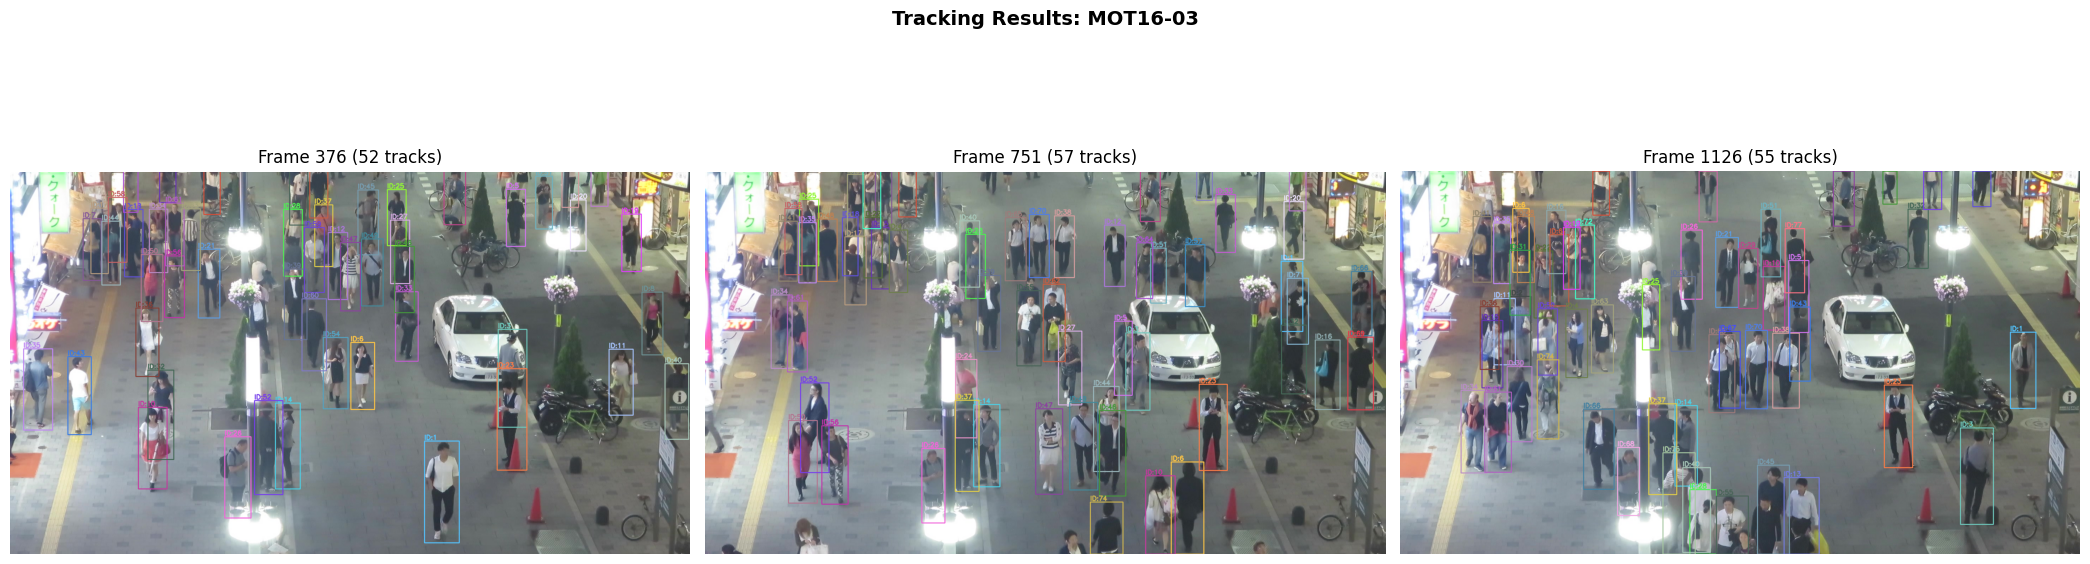

In [ ]:
# Show a few sample frames as static images
def show_sample_frames(seq_path, results, frame_indices=None):
    frames_dir = seq_path / 'img1'
    frame_files = sorted(frames_dir.glob('*.jpg'))

    if frame_indices is None:
        total = len(frame_files)
        frame_indices = [total // 4, total // 2, 3 * total // 4]

    fig, axes = plt.subplots(1, len(frame_indices), figsize=(7 * len(frame_indices), 7))
    if len(frame_indices) == 1:
        axes = [axes]

    for ax, fidx in zip(axes, frame_indices):
        frame = cv2.imread(str(frame_files[fidx]))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Draw tracks for this frame
        frame_tracks = [(tid, x, y, w, h) for (f, tid, x, y, w, h) in results if f == fidx + 1]
        for tid, x, y, w, h in frame_tracks:
            rng = random.Random(tid)
            color = (rng.randint(50, 255), rng.randint(50, 255), rng.randint(50, 255))
            cv2.rectangle(frame, (x, y), (x + w, y + h), color, 2)
            cv2.putText(frame, f"ID:{tid}", (x, y - 4),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        ax.imshow(frame)
        ax.set_title(f"Frame {fidx + 1} ({len(frame_tracks)} tracks)")
        ax.axis('off')

    plt.suptitle(f"Tracking Results: {seq_path.name}", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_sample_frames(seq_path, results)